# Baseline model for batch monitoring example

In [1]:
# Necessary import
import requests # for downloading data from the internet, enabling reuse in pipelines
import datetime # for time-related operations
import pandas as pd # for data manipulation

from evidently import DataDefinition
from evidently import Dataset
from evidently import Report
from evidently.metrics import ValueDrift, DriftedColumnsCount, MissingValueCount

from joblib import load, dump # for model saving/loading
from tqdm import tqdm # for progress bars during downloads

# For linear regression modeling and evaluation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [2]:
# create folder to store datasets and reference data
! mkdir data

In [3]:
# Define a list of tuples with filenames and their corresponding local save paths in the data folder
files = [('green_tripdata_2022-02.parquet', './data'), ('green_tripdata_2022-01.parquet', './data')]

print("Download files:")
# Iterate through the list to download files from URLs 
# dynamically generated for January and February 2022 green taxi trip data
for file, path in files:
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{file}"
    # Streaming download
    resp = requests.get(url, stream = True)
    save_path = f"{path}/{file}" # path for saving files
    with open(save_path, "wb") as handle:
        for data in tqdm(resp.iter_content(),
                        desc = f"{file}",
                        postfix = f"save to {save_path}",
                        total = int(resp.headers["Content-Length"])):
            handle.write(data) # writing the data

Download files:


green_tripdata_2022-01.parquet: 100%|██████████| 1254291/1254291 [00:03<00:00, 329225.18it/s, save to ./data/green_tripdata_2022-01.parquet]


In [4]:
# Read he January data set
jan_data = pd.read_parquet('data/green_tripdata_2022-01.parquet')
# Data description
jan_data.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,62495.000000,62495,62495,56200.000000,62495.000000,62495.000000,56200.000000,62495.000000,62495.000000,62495.00000,62495.000000,62495.000000,62495.000000,62495.000000,62495.000000,56200.000000,56200.000000,56200.000000
mean,1.849508,2022-01-16 14:18:36.026354,2022-01-16 14:37:37.189551,1.198719,97.615041,135.969902,1.258399,77.758632,13.914000,0.34756,0.426322,1.666540,0.208182,0.297312,17.490532,1.403594,1.040925,0.706628
min,1.000000,2009-01-01 00:34:01,2009-01-01 17:05:20,1.000000,1.000000,1.000000,0.000000,0.000000,-65.000000,-4.50000,-0.500000,-0.860000,-6.550000,-0.300000,-71.850000,1.000000,1.000000,0.000000
25%,2.000000,2022-01-08 23:41:50,2022-01-08 23:55:28.500000,1.000000,55.000000,74.000000,1.000000,1.080000,7.000000,0.00000,0.500000,0.000000,0.000000,0.300000,9.360000,1.000000,1.000000,0.000000
50%,2.000000,2022-01-16 15:59:42,2022-01-16 16:17:00,1.000000,75.000000,137.000000,1.000000,1.900000,10.500000,0.00000,0.500000,1.000000,0.000000,0.300000,13.860000,1.000000,1.000000,0.000000
75%,2.000000,2022-01-24 09:16:50,2022-01-24 09:37:28,1.000000,130.000000,215.000000,1.000000,3.500000,17.000000,0.50000,0.500000,2.610000,0.000000,0.300000,21.050000,2.000000,1.000000,2.750000
max,2.000000,2022-01-31 23:57:37,2022-02-01 21:01:54,5.000000,265.000000,265.000000,8.000000,224481.380000,604.500000,4.50000,0.500000,76.770000,44.750000,0.300000,605.300000,5.000000,2.000000,2.750000
std,0.357556,NaN,NaN,0.862313,62.987311,77.590956,0.877743,2909.354163,12.088819,0.65781,0.181381,2.484928,1.257659,0.037201,13.623416,0.516316,0.198119,1.201632


In [5]:
# Shape of the data
jan_data.shape

(62495, 20)

In [6]:
# Create target variable as trip duration 
jan_data["duration_min"] = jan_data.lpep_dropoff_datetime - jan_data.lpep_pickup_datetime
# Make sure the duration is in minutes
jan_data.duration_min = jan_data.duration_min.apply(lambda td : float(td.total_seconds())/60)

In [7]:
# Filter out outliers
jan_data = jan_data[(jan_data.duration_min >= 0) & (jan_data.duration_min <= 60)]
jan_data = jan_data[(jan_data.passenger_count > 0) & (jan_data.passenger_count <= 8)]

<Axes: >

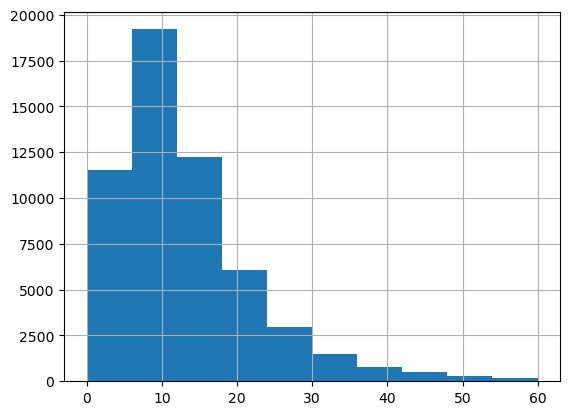

In [8]:
# Analyze target distribution
jan_data.duration_min.hist()

In [9]:
# Data labeling / Selecting features
target = "duration_min"
num_features = ["passenger_count", "trip_distance", "fare_amount", "total_amount"]
cat_features = ["PULocationID", "DOLocationID"]

In [10]:
# Check the shape of the data after cleaning
jan_data.shape

(55211, 21)

In [11]:
# Train and validation splitting
train_data = jan_data[:30000]
val_data = jan_data[30000:]

In [12]:
# Initialize the model
model = LinearRegression()
# Model fitting
model.fit(train_data[num_features + cat_features], train_data[target])

LinearRegression()

In [13]:
# Make train predictions
train_preds = model.predict(train_data[num_features + cat_features])
# Saving the predictions
train_data['prediction'] = train_preds

In [14]:
# Make the validation predictions
val_preds = model.predict(val_data[num_features + cat_features])
# Save validation predictions
val_data['prediction'] = val_preds

In [15]:
# Training and Validation MAE
print("Train MAE:", mean_absolute_error(train_data.duration_min, train_data.prediction))
print("Validation MAE:", mean_absolute_error(val_data.duration_min, val_data.prediction))

Train MAE: 3.804665373785086
Validation MAE: 4.1420640736884735


# Dump model and reference data

In [16]:
# Create folder to store trained models
! mkdir models

In [17]:
# Save the model
with open('models/lin_reg.bin', 'wb') as f_out:
    dump(model, f_out)

In [18]:
# Save the validation data for reference
val_data.to_parquet('data/reference.parquet')

# Evidently Report

In [ ]:
data_definition = DataDefinition(numerical_columns=num_features + ['prediction'], categorical_columns=cat_features)
train_dataset = Dataset.from_pandas(
    train_data,
    data_definition
)

val_dataset = Dataset.from_pandas(
    val_data,
    data_definition
)

In [ ]:
report = Report(metrics=[
    ValueDrift(column='prediction'),
    DriftedColumnsCount(),
    MissingValueCount(column='prediction'),
]
)

In [ ]:
snapshot = report.run(reference_data=train_dataset, current_data=val_dataset)

In [ ]:
snapshot

In [ ]:
result = snapshot.dict()

In [ ]:
result

In [ ]:
#prediction drift
result['metrics'][0]['value']

In [ ]:
#number of drifted columns
result['metrics'][1]['value']['count']

In [ ]:
#share of missing values
result['metrics'][2]['value']['count']

# Evidently Dashboard

In [ ]:
from evidently.presets import DataDriftPreset, DataSummaryPreset

from evidently.ui.workspace import Workspace
from evidently.sdk.panels import *
from evidently.legacy.renderers.html_widgets import WidgetSize

In [ ]:
ws = Workspace("workspace")

In [ ]:
project = ws.create_project("NYC Taxi Data Quality Project")
project.description = "My project description"
project.save()

In [ ]:
regular_report = Report(
    metrics=[
        DataSummaryPreset()
    ],
)

data = Dataset.from_pandas(
    val_data.loc[val_data.lpep_pickup_datetime.between('2022-01-28', '2022-01-29', inclusive="left")],
    data_definition=data_definition,
)

regular_snapshot = regular_report.run(current_data=data, timestamp=datetime.datetime(2022,1,28))

regular_snapshot

In [ ]:
ws.add_run(project.id, regular_snapshot)

note: To view a report please run "evidently ui" command in a separate tab in your terminal.

In [ ]:
#configure the dashboard
project.dashboard.add_panel(
    text_panel(title="NYC taxi data dashboard")
)

project.dashboard.add_panel(
    bar_plot_panel(
        title="Inference Count",
        values=[
            PanelMetric(
                metric="RowCount",
                legend="count",
            ),
        ],
        size="half",
    ),
)

project.dashboard.add_panel(
    line_plot_panel(
        title="Number of Missing Values",
        values=[
            PanelMetric(
                metric="DatasetMissingValueCount",
                legend="count"
            ),
        ],
        size="half",
    ),
)

project.save()

To view a dashboard please run "evidently ui" command in a separate tab in your terminal.

In [ ]:
regular_report = Report(
    metrics=[
        DataSummaryPreset()
    ],
)

data = Dataset.from_pandas(
    val_data.loc[val_data.lpep_pickup_datetime.between('2022-01-29', '2022-01-30', inclusive="left")],
    data_definition=data_definition,
)

regular_run = regular_report.run(current_data=data, timestamp=datetime.datetime(2022,1,29))

regular_run

In [ ]:
ws.add_run(project.id, regular_run)

---